# Big Data Programming Project
## Detecting unusual municipality-year energy profiles in Sweden

## 1. Project overview

`Jakob Wennergrund & Robin Dogan`

This project investigates whether anomaly detection can identify municipality-year observations with unusual energy profiles in Swedish municipal energy data.

The analysis combines three parts of the municipal energy system:
- final energy use,
- electricity production,
- district heating production.

The goal is not to predict a labeled target. Instead, the goal is to detect observations that differ from the general multivariate pattern in the data.

This project follows a clear workflow:

1. define the problem and research question,
2. describe and examine the data sources,
3. prepare, clean, and integrate the data,
4. construct the feature matrix,
5. train and tune the anomaly detection models,
6. evaluate anomaly scores and apply threshold-based selection,
7. compare anomaly rankings across methods,
8. discuss interpretation, limitations, practical use, and scalability.

## 2. Problem and investigation question

Municipal energy systems differ across Sweden. Some differences are expected, while others may reflect unusual combinations of consumption, production, or fuel structure.

The problem addressed in this project is how to identify municipality-year observations that look unusual when several energy dimensions are considered together.

### Investigation question
Can anomaly detection identify municipality-year observations with unusual energy profiles in Swedish municipal energy data?

### Final project objective
The objective is to build an unsupervised workflow that combines final energy use, electricity production, and district heating data, and then detect observations that deviate from the general pattern.

## 3. Data sources

This project uses official Swedish municipal energy data from Statistics Sweden (SCB).

Three data sources are used in the project. Each source is provided in two files split by time period.

1. **Final energy use**  
   This dataset describes how much energy is used in different consumption categories.

2. **Electricity production and fuel use**  
   This dataset describes electricity production by production type and fuel type.

3. **District heating production and fuel use**  
   This dataset describes district heating production by production type and fuel type.

The datasets cover Swedish municipalities over multiple years and together describe important parts of the local energy system.

### Why these datasets were selected

These datasets were selected because the project aims to detect unusual municipality-year energy profiles.

A municipality-year profile should reflect more than one part of the energy system. Final energy use shows demand, while electricity production and district heating production show important supply-side characteristics.

By combining these datasets, the analysis can capture broader energy patterns than any single dataset alone.

### Data format and structure

The original data is stored as CSV files.

The source tables are not yet in the format needed for anomaly detection. They contain categorical dimensions such as municipality, year, fuel type, production type, and consumption category.

To support the analysis, the data must be transformed into a municipality-year feature matrix where:
- each row represents one municipality in one year,
- each column represents one feature,
- each cell contains a numeric value used for modeling.

### Files used in the project

The following files are used:

- final energy use, 2005–2008
- final energy use, 2009–2023
- electricity production and fuel use, 2005–2008
- electricity production and fuel use, 2009–2023
- district heating production and fuel use, 2005–2008
- district heating production and fuel use, 2009–2023

The files are split by time period, so each pair must first be combined before the full datasets can be prepared and integrated.

## 4. Data preparation

The source data is not yet in a format that can be used for anomaly detection.

This section prepares the data in a structured sequence:
1. combine files from different time periods,
2. inspect the raw tables,
3. reshape the data,
4. integrate the three sources,
5. build the final municipality-year table.

### 4.1 Combine files within each data source

Each data source is split into two files by time period.

The files are first read and combined so that each source becomes one complete table.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

In [2]:
data_dir = Path.cwd() / "data"

In [3]:
files = {
    "use_0508": data_dir / "Slutanvändning (MWh), efter län och kommun, förbrukarkategori samt bränsletyp. År 2005 - 2008.csv",
    "use_0923": data_dir / "Slutanvändning (MWh), efter län och kommun, förbrukarkategori samt bränsletyp. År 2009 - 2023.csv",
    "el_0508": data_dir / "Elproduktion och bränsleanvändning (MWh), efter län och kommun, produktionssätt samt bränsletyp. År 2005 - 2008.csv",
    "el_0923": data_dir / "Elproduktion och bränsleanvändning (MWh), efter län och kommun, produktionssätt samt bränsletyp. År 2009 - 2023.csv",
    "heat_0508": data_dir / "Fjärrvärmeproduktion och bränsleanvändning (MWh), efter län och kommun, produktionssätt samt bränsletyp. År 2005 - 2008.csv",
    "heat_0923": data_dir / "Fjärrvärmeproduktion och bränsleanvändning (MWh), efter län och kommun, produktionssätt samt bränsletyp. År 2009 - 2023.csv",
}

In [4]:
use_a = pd.read_csv(files["use_0508"], encoding="latin1", sep=",")
use_b = pd.read_csv(files["use_0923"], encoding="latin1", sep=",")

el_a = pd.read_csv(files["el_0508"], encoding="latin1", sep=",")
el_b = pd.read_csv(files["el_0923"], encoding="latin1", sep=",")

heat_a = pd.read_csv(files["heat_0508"], encoding="latin1", sep=",")
heat_b = pd.read_csv(files["heat_0923"], encoding="latin1", sep=",")

In [5]:
use_raw = pd.concat([use_a, use_b], ignore_index=True)
el_raw = pd.concat([el_a, el_b], ignore_index=True)
heat_raw = pd.concat([heat_a, heat_b], ignore_index=True)

In [6]:
print("Final energy use:", use_raw.shape)
print("Electricity production:", el_raw.shape)
print("District heating:", heat_raw.shape)

Final energy use: (491760, 5)
Electricity production: (269712, 5)
District heating: (340956, 5)


### 4.2 Inspect the raw structure

The next step is to inspect the combined source tables.

This is done to identify:
- the key columns,
- the value columns,
- and the overall structure of the data.

In [7]:
# Preview final energy use table
use_raw.head()

,region,förbrukarkategori,bränsletyp,år,Slutanvändning (MWh)
0,00 Riket,"slutanv. jordbruk,skogsbruk,fiske",flytande (icke förnybara),2005,4195950
1,00 Riket,"slutanv. jordbruk,skogsbruk,fiske",flytande (icke förnybara),2006,4158066
2,00 Riket,"slutanv. jordbruk,skogsbruk,fiske",flytande (icke förnybara),2007,3689400
3,00 Riket,"slutanv. jordbruk,skogsbruk,fiske",flytande (icke förnybara),2008,4003198
4,00 Riket,"slutanv. jordbruk,skogsbruk,fiske",fast (icke förnybara),2005,0


In [8]:
# Preview electricity production table
el_raw.head()

,region,produktionssätt,bränsletyp,år,Elproduktion och bränsleanvändning (MWh)
0,00 Riket,kraftvärmeverk + industriellt mottryck,elproduktion,2005,12064884
1,00 Riket,kraftvärmeverk + industriellt mottryck,elproduktion,2006,12760970
2,00 Riket,kraftvärmeverk + industriellt mottryck,elproduktion,2007,13531303
3,00 Riket,kraftvärmeverk + industriellt mottryck,elproduktion,2008,13831977
4,00 Riket,kraftvärmeverk + industriellt mottryck,flytande (icke förnybara),2005,..


In [9]:
# Preview district heating table
heat_raw.head()

,region,produktionssätt,bränsletyp,år,Fjärrvärmeproduktion och bränsleanvändning (MWh)
0,00 Riket,kraftvärmeverk,fjärrvärmeproduktion,2005,28878151
1,00 Riket,kraftvärmeverk,fjärrvärmeproduktion,2006,31540649
2,00 Riket,kraftvärmeverk,fjärrvärmeproduktion,2007,30934340
3,00 Riket,kraftvärmeverk,fjärrvärmeproduktion,2008,29740485
4,00 Riket,kraftvärmeverk,flytande (icke förnybara),2005,1532682


In [10]:
# Show column names
print("Final energy use columns:")
print(use_raw.columns.tolist())

print("\nElectricity production columns:")
print(el_raw.columns.tolist())

print("\nDistrict heating columns:")
print(heat_raw.columns.tolist())

Final energy use columns:
['region', 'förbrukarkategori', 'bränsletyp', 'år', 'Slutanvändning (MWh)']

Electricity production columns:
['region', 'produktionssätt', 'bränsletyp', 'år', 'Elproduktion och bränsleanvändning (MWh)']

District heating columns:
['region', 'produktionssätt', 'bränsletyp', 'år', 'Fjärrvärmeproduktion och bränsleanvändning (MWh)']


In [11]:
# Show data types
print("Final energy use dtypes:")
print(use_raw.dtypes)

print("\nElectricity production dtypes:")
print(el_raw.dtypes)

print("\nDistrict heating dtypes:")
print(heat_raw.dtypes)

Final energy use dtypes:
region                  object
förbrukarkategori       object
bränsletyp              object
år                       int64
Slutanvändning (MWh)    object
dtype: object

Electricity production dtypes:
region                                      object
produktionssätt                             object
bränsletyp                                  object
år                                           int64
Elproduktion och bränsleanvändning (MWh)    object
dtype: object

District heating dtypes:
region                                              object
produktionssätt                                     object
bränsletyp                                          object
år                                                   int64
Fjärrvärmeproduktion och bränsleanvändning (MWh)    object
dtype: object


The inspection shows that the tables already follow a long-format structure.

Each row represents one region, one year, one category combination, and one value. No additional reshaping is needed at this stage.

### 4.3 Clean and standardize the tables

The three source tables must be standardized before they can be integrated.

This step:
- renames key columns,
- converts missing markers to null values,
- converts the value columns to numeric format,
- and creates a consistent structure across the three sources.

In [12]:
# Copy tables before cleaning
use = use_raw.copy()
el = el_raw.copy()
heat = heat_raw.copy()

In [13]:
# Rename columns to a consistent format
use = use.rename(columns={
    "år": "year",
    "Slutanvändning (MWh)": "value"
})

el = el.rename(columns={
    "år": "year",
    "Elproduktion och bränsleanvändning (MWh)": "value"
})

heat = heat.rename(columns={
    "år": "year",
    "Fjärrvärmeproduktion och bränsleanvändning (MWh)": "value"
})

In [14]:
# Replace SCB missing markers with NaN
use["value"] = use["value"].replace("..", np.nan)
el["value"] = el["value"].replace("..", np.nan)
heat["value"] = heat["value"].replace("..", np.nan)

In [15]:
# Convert year and value columns to numeric format
use["year"] = pd.to_numeric(use["year"], errors="coerce")
use["value"] = pd.to_numeric(use["value"], errors="coerce")

el["year"] = pd.to_numeric(el["year"], errors="coerce")
el["value"] = pd.to_numeric(el["value"], errors="coerce")

heat["year"] = pd.to_numeric(heat["year"], errors="coerce")
heat["value"] = pd.to_numeric(heat["value"], errors="coerce")

In [16]:
# Check the standardized structure
print("Final energy use:")
print(use.dtypes)

print("\nElectricity production:")
print(el.dtypes)

print("\nDistrict heating:")
print(heat.dtypes)

Final energy use:
region                object
förbrukarkategori     object
bränsletyp            object
year                   int64
value                float64
dtype: object

Electricity production:
region              object
produktionssätt     object
bränsletyp          object
year                 int64
value              float64
dtype: object

District heating:
region              object
produktionssätt     object
bränsletyp          object
year                 int64
value              float64
dtype: object


In [17]:
# Preview cleaned tables
display(use.head())
display(el.head())
display(heat.head())

,region,förbrukarkategori,bränsletyp,year,value
0,00 Riket,"slutanv. jordbruk,skogsbruk,fiske",flytande (icke förnybara),2005,4195950.0
1,00 Riket,"slutanv. jordbruk,skogsbruk,fiske",flytande (icke förnybara),2006,4158066.0
2,00 Riket,"slutanv. jordbruk,skogsbruk,fiske",flytande (icke förnybara),2007,3689400.0
3,00 Riket,"slutanv. jordbruk,skogsbruk,fiske",flytande (icke förnybara),2008,4003198.0
4,00 Riket,"slutanv. jordbruk,skogsbruk,fiske",fast (icke förnybara),2005,0.0


,region,produktionssätt,bränsletyp,year,value
0,00 Riket,kraftvärmeverk + industriellt mottryck,elproduktion,2005,12064884.0
1,00 Riket,kraftvärmeverk + industriellt mottryck,elproduktion,2006,12760970.0
2,00 Riket,kraftvärmeverk + industriellt mottryck,elproduktion,2007,13531303.0
3,00 Riket,kraftvärmeverk + industriellt mottryck,elproduktion,2008,13831977.0
4,00 Riket,kraftvärmeverk + industriellt mottryck,flytande (icke förnybara),2005,NaN


,region,produktionssätt,bränsletyp,year,value
0,00 Riket,kraftvärmeverk,fjärrvärmeproduktion,2005,28878151.0
1,00 Riket,kraftvärmeverk,fjärrvärmeproduktion,2006,31540649.0
2,00 Riket,kraftvärmeverk,fjärrvärmeproduktion,2007,30934340.0
3,00 Riket,kraftvärmeverk,fjärrvärmeproduktion,2008,29740485.0
4,00 Riket,kraftvärmeverk,flytande (icke förnybara),2005,1532682.0


The three tables now have a consistent structure.

The year column is numeric, the value column has been standardized, and SCB missing markers such as `..` have been converted to null values. This makes the tables easier to filter, reshape, and merge in the next steps.

### 4.4 Remove national and county summary rows

The analysis is performed at municipality-year level.

Rows for `Riket` and rows for counties (`län`) are removed because they do not represent individual municipalities. Keeping them would mix different levels of observation in the same analysis.

In [18]:
# Check region values before removal
print(use["region"].head())
print(el["region"].head())
print(heat["region"].head())

0    00 Riket
1    00 Riket
2    00 Riket
3    00 Riket
4    00 Riket
Name: region, dtype: object
0    00 Riket
1    00 Riket
2    00 Riket
3    00 Riket
4    00 Riket
Name: region, dtype: object
0    00 Riket
1    00 Riket
2    00 Riket
3    00 Riket
4    00 Riket
Name: region, dtype: object


In [19]:
# Remove national summary rows
use = use[~use["region"].str.contains("Riket", na=False)].copy()
el = el[~el["region"].str.contains("Riket", na=False)].copy()
heat = heat[~heat["region"].str.contains("Riket", na=False)].copy()

# Remove county rows
use = use[~use["region"].str.contains("län", case=False, na=False)].copy()
el = el[~el["region"].str.contains("län", case=False, na=False)].copy()
heat = heat[~heat["region"].str.contains("län", case=False, na=False)].copy()

In [20]:
# Show dataset shapes after removal
print("Final energy use:", use.shape)
print("Electricity production:", el.shape)
print("District heating:", heat.shape)

Final energy use: (455535, 5)
Electricity production: (249840, 5)
District heating: (315840, 5)


In [21]:
# Preview tables after removal
display(use.head())
display(el.head())
display(heat.head())

,region,förbrukarkategori,bränsletyp,year,value
7920,0114 Upplands Väsby,"slutanv. jordbruk,skogsbruk,fiske",flytande (icke förnybara),2005,3200.0
7921,0114 Upplands Väsby,"slutanv. jordbruk,skogsbruk,fiske",flytande (icke förnybara),2006,3079.0
7922,0114 Upplands Väsby,"slutanv. jordbruk,skogsbruk,fiske",flytande (icke förnybara),2007,2458.0
7923,0114 Upplands Väsby,"slutanv. jordbruk,skogsbruk,fiske",flytande (icke förnybara),2008,4967.0
7924,0114 Upplands Väsby,"slutanv. jordbruk,skogsbruk,fiske",fast (icke förnybara),2005,0.0


,region,produktionssätt,bränsletyp,year,value
3168,0114 Upplands Väsby,kraftvärmeverk + industriellt mottryck,elproduktion,2005,0.0
3169,0114 Upplands Väsby,kraftvärmeverk + industriellt mottryck,elproduktion,2006,0.0
3170,0114 Upplands Väsby,kraftvärmeverk + industriellt mottryck,elproduktion,2007,0.0
3171,0114 Upplands Väsby,kraftvärmeverk + industriellt mottryck,elproduktion,2008,0.0
3172,0114 Upplands Väsby,kraftvärmeverk + industriellt mottryck,flytande (icke förnybara),2005,0.0


,region,produktionssätt,bränsletyp,year,value
5544,0114 Upplands Väsby,kraftvärmeverk,fjärrvärmeproduktion,2005,0.0
5545,0114 Upplands Väsby,kraftvärmeverk,fjärrvärmeproduktion,2006,0.0
5546,0114 Upplands Väsby,kraftvärmeverk,fjärrvärmeproduktion,2007,0.0
5547,0114 Upplands Väsby,kraftvärmeverk,fjärrvärmeproduktion,2008,0.0
5548,0114 Upplands Väsby,kraftvärmeverk,flytande (icke förnybara),2005,0.0


In [22]:
# Check remaining region values
print("Final energy use regions:", use["region"].nunique())
print("Electricity production regions:", el["region"].nunique())
print("District heating regions:", heat["region"].nunique())

print("\nExample municipality values:")
print(sorted(use["region"].dropna().unique())[:20])

Final energy use regions: 290
Electricity production regions: 290
District heating regions: 290

Example municipality values:
['0114 Upplands Väsby', '0115 Vallentuna', '0117 Österåker', '0120 Värmdö', '0123 Järfälla', '0125 Ekerö', '0126 Huddinge', '0127 Botkyrka', '0128 Salem', '0136 Haninge', '0138 Tyresö', '0139 Upplands-Bro', '0140 Nykvarn', '0160 Täby', '0162 Danderyd', '0163 Sollentuna', '0180 Stockholm', '0181 Södertälje', '0182 Nacka', '0183 Sundbyberg']


The `Riket` rows and the county rows have now been removed from all three tables.

The remaining rows represent municipalities, which makes the data suitable for municipality-year analysis.

### 4.5 Create one row per municipality and year

The model will treat each municipality-year as one observation.

The source tables still contain several rows for the same municipality-year because different categories are stored separately. In this step, the tables are reorganized so that each municipality-year has one row and the category values become separate columns.

In [23]:
# Rename region column to match the analysis level
use = use.rename(columns={"region": "municipality"})
el = el.rename(columns={"region": "municipality"})
heat = heat.rename(columns={"region": "municipality"})

In [24]:
# Check fuel-type labels before aggregation
print("Final energy use fuel types:")
print(sorted(use["bränsletyp"].dropna().unique())[:20])

print("\nElectricity production fuel types:")
print(sorted(el["bränsletyp"].dropna().unique())[:20])

print("\nDistrict heating fuel types:")
print(sorted(heat["bränsletyp"].dropna().unique())[:20])

Final energy use fuel types:
['el', 'fast (förnybara)', 'fast (icke förnybara)', 'fjärrvärme', 'flytande (förnybara)', 'flytande (icke förnybara)', 'gas (förnybara)', 'gas (icke förnybara)', 'totalt', 'övriga']

Electricity production fuel types:
['elproduktion', 'fast (förnybara)', 'fast (icke förnybara)', 'flytande (förnybara)', 'flytande (icke förnybara)', 'gas (förnybara)', 'gas (icke förnybara)', 'totalt', 'övriga']

District heating fuel types:
['fast (förnybara)', 'fast (icke förnybara)', 'fjärrvärmeproduktion', 'flytande (förnybara)', 'flytande (icke förnybara)', 'gas (förnybara)', 'gas (icke förnybara)', 'totalt', 'övriga']


In [25]:
# Check fuel-type labels before aggregation
print("Final energy use fuel types:")
print(sorted(use["bränsletyp"].dropna().unique())[:20])

print("\nElectricity production fuel types:")
print(sorted(el["bränsletyp"].dropna().unique())[:20])

print("\nDistrict heating fuel types:")
print(sorted(heat["bränsletyp"].dropna().unique())[:20])

Final energy use fuel types:
['el', 'fast (förnybara)', 'fast (icke förnybara)', 'fjärrvärme', 'flytande (förnybara)', 'flytande (icke förnybara)', 'gas (förnybara)', 'gas (icke förnybara)', 'totalt', 'övriga']

Electricity production fuel types:
['elproduktion', 'fast (förnybara)', 'fast (icke förnybara)', 'flytande (förnybara)', 'flytande (icke förnybara)', 'gas (förnybara)', 'gas (icke förnybara)', 'totalt', 'övriga']

District heating fuel types:
['fast (förnybara)', 'fast (icke förnybara)', 'fjärrvärmeproduktion', 'flytande (förnybara)', 'flytande (icke förnybara)', 'gas (förnybara)', 'gas (icke förnybara)', 'totalt', 'övriga']


In [26]:
# Keep rows that represent the main category totals
use_tot = use[use["bränsletyp"].str.lower().isin(["totalt", "total"])].copy()
el_tot = el[el["bränsletyp"].str.lower() == "elproduktion"].copy()
heat_tot = heat[heat["bränsletyp"].str.lower() == "fjärrvärmeproduktion"].copy()

In [27]:
# Check the filtered tables
print("Final energy use:", use_tot.shape)
print("Electricity production:", el_tot.shape)
print("District heating:", heat_tot.shape)

display(use_tot.head())
display(el_tot.head())
display(heat_tot.head())

Final energy use: (49455, 5)
Electricity production: (30650, 5)
District heating: (38465, 5)


,municipality,förbrukarkategori,bränsletyp,year,value
7956,0114 Upplands Väsby,"slutanv. jordbruk,skogsbruk,fiske",totalt,2005,3275.0
7957,0114 Upplands Väsby,"slutanv. jordbruk,skogsbruk,fiske",totalt,2006,3157.0
7958,0114 Upplands Väsby,"slutanv. jordbruk,skogsbruk,fiske",totalt,2007,4843.0
7959,0114 Upplands Väsby,"slutanv. jordbruk,skogsbruk,fiske",totalt,2008,7230.0
7996,0114 Upplands Väsby,"slutanv. industri, byggverks.",totalt,2005,NaN


,municipality,produktionssätt,bränsletyp,year,value
3168,0114 Upplands Väsby,kraftvärmeverk + industriellt mottryck,elproduktion,2005,0.0
3169,0114 Upplands Väsby,kraftvärmeverk + industriellt mottryck,elproduktion,2006,0.0
3170,0114 Upplands Väsby,kraftvärmeverk + industriellt mottryck,elproduktion,2007,0.0
3171,0114 Upplands Väsby,kraftvärmeverk + industriellt mottryck,elproduktion,2008,0.0
3204,0114 Upplands Väsby,"övrig värmekraft (kärnkraft, kondenskraft o.dyl.)",elproduktion,2005,0.0


,municipality,produktionssätt,bränsletyp,year,value
5544,0114 Upplands Väsby,kraftvärmeverk,fjärrvärmeproduktion,2005,0.0
5545,0114 Upplands Väsby,kraftvärmeverk,fjärrvärmeproduktion,2006,0.0
5546,0114 Upplands Väsby,kraftvärmeverk,fjärrvärmeproduktion,2007,0.0
5547,0114 Upplands Väsby,kraftvärmeverk,fjärrvärmeproduktion,2008,0.0
5580,0114 Upplands Väsby,fristående värmeverk,fjärrvärmeproduktion,2005,0.0


The selected rows are now reorganized so that each municipality-year becomes one row.

The category column is turned into several feature columns, and the value column is used to fill those features.

In [28]:
# Pivot final energy use to municipality-year level
use_wide = use_tot.pivot_table(
    index=["municipality", "year"],
    columns="förbrukarkategori",
    values="value",
    aggfunc="sum"
)

In [29]:
# Pivot electricity production to municipality-year level
el_wide = el_tot.pivot_table(
    index=["municipality", "year"],
    columns="produktionssätt",
    values="value",
    aggfunc="sum"
)

In [30]:
# Pivot district heating production to municipality-year level
heat_wide = heat_tot.pivot_table(
    index=["municipality", "year"],
    columns="produktionssätt",
    values="value",
    aggfunc="sum"
)

In [31]:
# Add source prefixes to feature names
use_wide.columns = [f"use__{c}" for c in use_wide.columns]
el_wide.columns = [f"el__{c}" for c in el_wide.columns]
heat_wide.columns = [f"heat__{c}" for c in heat_wide.columns]

In [32]:
# Convert index back to columns
use_wide = use_wide.reset_index()
el_wide = el_wide.reset_index()
heat_wide = heat_wide.reset_index()

In [33]:
# Show the aggregated tables
print("Final energy use wide shape:", use_wide.shape)
print("Electricity production wide shape:", el_wide.shape)
print("District heating wide shape:", heat_wide.shape)

display(use_wide.head())
display(el_wide.head())
display(heat_wide.head())

Final energy use wide shape: (5495, 11)
Electricity production wide shape: (5495, 8)
District heating wide shape: (5495, 9)


,municipality,year,use__slutanv. flerbostadshus,use__slutanv. fritidshus,"use__slutanv. industri, byggverks.","use__slutanv. jordbruk,skogsbruk,fiske",use__slutanv. offentlig verksamhet,use__slutanv. småhus,use__slutanv. transporter,use__slutanv. övriga tjänster,use__totalt
0,0114 Upplands Väsby,2005,159128.0,1000.0,0.0,3275.0,90764.0,135473.0,400385.0,140385.0,0.0
1,0114 Upplands Väsby,2006,151794.0,1023.0,0.0,3157.0,96962.0,137616.0,411324.0,142995.0,0.0
2,0114 Upplands Väsby,2007,168616.0,921.0,0.0,4843.0,83745.0,132198.0,421843.0,152285.0,0.0
3,0114 Upplands Väsby,2008,143209.0,893.0,0.0,7230.0,57484.0,114154.0,409333.0,175112.0,0.0
4,0114 Upplands Väsby,2009,26014.0,0.0,81926.0,5879.0,38547.0,123378.0,418706.0,157200.0,851649.0


,municipality,year,el__kraftvärmeverk + industriellt mottryck,el__solkraft,el__totalt,el__vattenkraft,el__vindkraft,"el__övrig värmekraft (kärnkraft, kondenskraft o.dyl.)"
0,0114 Upplands Väsby,2005,0.0,NaN,0.0,0.0,NaN,0.0
1,0114 Upplands Väsby,2006,0.0,NaN,0.0,0.0,NaN,0.0
2,0114 Upplands Väsby,2007,0.0,NaN,0.0,0.0,NaN,0.0
3,0114 Upplands Väsby,2008,0.0,NaN,0.0,0.0,NaN,0.0
4,0114 Upplands Väsby,2009,0.0,0.0,0.0,0.0,0.0,0.0


,municipality,year,heat__elpannor (1),heat__fristående värmeverk,heat__kraftvärmeverk,heat__rökgaskondens,heat__spillvärme,heat__totalt,heat__värmepumpar (2)
0,0114 Upplands Väsby,2005,3108.0,0.0,0.0,0.0,0.0,3108.0,0.0
1,0114 Upplands Väsby,2006,138.0,0.0,0.0,0.0,0.0,138.0,0.0
2,0114 Upplands Väsby,2007,6.0,0.0,0.0,0.0,0.0,6.0,0.0
3,0114 Upplands Väsby,2008,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0114 Upplands Väsby,2009,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Each source now has one row per municipality-year.

These tables can now be merged into one dataset for anomaly detection.

### 4.6 Merge the source tables

The three source tables must now be combined into one dataset.

This step creates one municipality-year table that includes features from final energy use, electricity production, and district heating.

In [34]:
# Merge the three municipality-year tables
df = use_wide.merge(el_wide, on=["municipality", "year"], how="outer")
df = df.merge(heat_wide, on=["municipality", "year"], how="outer")

In [35]:
# Show merged dataset shape
print("Merged dataset shape:", df.shape)

Merged dataset shape: (5495, 24)


In [36]:
# Preview merged dataset
df.head()

,municipality,year,use__slutanv. flerbostadshus,use__slutanv. fritidshus,"use__slutanv. industri, byggverks.","use__slutanv. jordbruk,skogsbruk,fiske",use__slutanv. offentlig verksamhet,use__slutanv. småhus,use__slutanv. transporter,use__slutanv. övriga tjänster,...,el__vattenkraft,el__vindkraft,"el__övrig värmekraft (kärnkraft, kondenskraft o.dyl.)",heat__elpannor (1),heat__fristående värmeverk,heat__kraftvärmeverk,heat__rökgaskondens,heat__spillvärme,heat__totalt,heat__värmepumpar (2)
0,0114 Upplands Väsby,2005,159128.0,1000.0,0.0,3275.0,90764.0,135473.0,400385.0,140385.0,...,0.0,NaN,0.0,3108.0,0.0,0.0,0.0,0.0,3108.0,0.0
1,0114 Upplands Väsby,2006,151794.0,1023.0,0.0,3157.0,96962.0,137616.0,411324.0,142995.0,...,0.0,NaN,0.0,138.0,0.0,0.0,0.0,0.0,138.0,0.0
2,0114 Upplands Väsby,2007,168616.0,921.0,0.0,4843.0,83745.0,132198.0,421843.0,152285.0,...,0.0,NaN,0.0,6.0,0.0,0.0,0.0,0.0,6.0,0.0
3,0114 Upplands Väsby,2008,143209.0,893.0,0.0,7230.0,57484.0,114154.0,409333.0,175112.0,...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0114 Upplands Väsby,2009,26014.0,0.0,81926.0,5879.0,38547.0,123378.0,418706.0,157200.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
# Check missing values after merging
df.isna().sum().sort_values(ascending=False).head(20)

el__solkraft                                             1160
el__vindkraft                                            1160
municipality                                                0
year                                                        0
use__slutanv. industri, byggverks.                          0
use__slutanv. jordbruk,skogsbruk,fiske                      0
use__slutanv. flerbostadshus                                0
use__slutanv. fritidshus                                    0
use__slutanv. småhus                                        0
use__slutanv. offentlig verksamhet                          0
use__slutanv. transporter                                   0
use__slutanv. övriga tjänster                               0
el__kraftvärmeverk + industriellt mottryck                  0
use__totalt                                                 0
el__totalt                                                  0
el__vattenkraft                                             0
el__övri

The three sources are now combined into one municipality-year dataset.

Each row represents one municipality and one year, while the columns describe different parts of the local energy system.

### 4.7 Inspect the merged municipality-year dataset

The merged table is inspected before the final feature setup.

This step checks the number of municipalities, the time coverage, and whether each row represents one municipality-year observation.

In [38]:
# Number of municipalities and years
print("Number of municipalities:", df["municipality"].nunique())
print("Number of years:", df["year"].nunique())

Number of municipalities: 290
Number of years: 19


In [39]:
# Year range
print("Year range:", df["year"].min(), "to", df["year"].max())

Year range: 2005 to 2023


In [40]:
# Preview municipality-year identifiers
df[["municipality", "year"]].head(10)

,municipality,year
0,0114 Upplands Väsby,2005
1,0114 Upplands Väsby,2006
2,0114 Upplands Väsby,2007
3,0114 Upplands Väsby,2008
4,0114 Upplands Väsby,2009
5,0114 Upplands Väsby,2010
6,0114 Upplands Väsby,2011
7,0114 Upplands Väsby,2012
8,0114 Upplands Väsby,2013
9,0114 Upplands Väsby,2014


In [41]:
# Check duplicate municipality-year rows
dup_count = df.duplicated(subset=["municipality", "year"]).sum()
print("Duplicate municipality-year rows:", dup_count)

Duplicate municipality-year rows: 0


In [42]:
# Preview merged dataset
df.head()

,municipality,year,use__slutanv. flerbostadshus,use__slutanv. fritidshus,"use__slutanv. industri, byggverks.","use__slutanv. jordbruk,skogsbruk,fiske",use__slutanv. offentlig verksamhet,use__slutanv. småhus,use__slutanv. transporter,use__slutanv. övriga tjänster,...,el__vattenkraft,el__vindkraft,"el__övrig värmekraft (kärnkraft, kondenskraft o.dyl.)",heat__elpannor (1),heat__fristående värmeverk,heat__kraftvärmeverk,heat__rökgaskondens,heat__spillvärme,heat__totalt,heat__värmepumpar (2)
0,0114 Upplands Väsby,2005,159128.0,1000.0,0.0,3275.0,90764.0,135473.0,400385.0,140385.0,...,0.0,NaN,0.0,3108.0,0.0,0.0,0.0,0.0,3108.0,0.0
1,0114 Upplands Väsby,2006,151794.0,1023.0,0.0,3157.0,96962.0,137616.0,411324.0,142995.0,...,0.0,NaN,0.0,138.0,0.0,0.0,0.0,0.0,138.0,0.0
2,0114 Upplands Väsby,2007,168616.0,921.0,0.0,4843.0,83745.0,132198.0,421843.0,152285.0,...,0.0,NaN,0.0,6.0,0.0,0.0,0.0,0.0,6.0,0.0
3,0114 Upplands Väsby,2008,143209.0,893.0,0.0,7230.0,57484.0,114154.0,409333.0,175112.0,...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0114 Upplands Väsby,2009,26014.0,0.0,81926.0,5879.0,38547.0,123378.0,418706.0,157200.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


The merged dataset now has one row per municipality and year.

This is the structure required for anomaly detection, where each municipality-year is treated as one observation.

### 4.8 Prepare the feature matrix and handle missing values

The model will use the energy variables as input features.

In this step, the municipality and year columns are kept as identifiers, while the energy columns are used to build the feature matrix. Missing values are then handled so the data can be used by the anomaly detection model.

In [43]:
# Select the columns that will be used as model features
feature_cols = [c for c in df.columns if c not in ["municipality", "year"]]

print("Number of feature columns:", len(feature_cols))
print(feature_cols)

Number of feature columns: 22
['use__slutanv. flerbostadshus', 'use__slutanv. fritidshus', 'use__slutanv. industri, byggverks.', 'use__slutanv. jordbruk,skogsbruk,fiske', 'use__slutanv. offentlig verksamhet', 'use__slutanv. småhus', 'use__slutanv. transporter', 'use__slutanv. övriga tjänster', 'use__totalt', 'el__kraftvärmeverk + industriellt mottryck', 'el__solkraft', 'el__totalt', 'el__vattenkraft', 'el__vindkraft', 'el__övrig värmekraft (kärnkraft, kondenskraft o.dyl.)', 'heat__elpannor (1)', 'heat__fristående värmeverk', 'heat__kraftvärmeverk', 'heat__rökgaskondens', 'heat__spillvärme', 'heat__totalt', 'heat__värmepumpar (2)']


In [44]:
# Create the raw feature matrix from the selected energy columns
X_raw = df[feature_cols].copy()

print("Raw feature matrix shape:", X_raw.shape)
X_raw.head()

Raw feature matrix shape: (5495, 22)


,use__slutanv. flerbostadshus,use__slutanv. fritidshus,"use__slutanv. industri, byggverks.","use__slutanv. jordbruk,skogsbruk,fiske",use__slutanv. offentlig verksamhet,use__slutanv. småhus,use__slutanv. transporter,use__slutanv. övriga tjänster,use__totalt,el__kraftvärmeverk + industriellt mottryck,...,el__vattenkraft,el__vindkraft,"el__övrig värmekraft (kärnkraft, kondenskraft o.dyl.)",heat__elpannor (1),heat__fristående värmeverk,heat__kraftvärmeverk,heat__rökgaskondens,heat__spillvärme,heat__totalt,heat__värmepumpar (2)
0,159128.0,1000.0,0.0,3275.0,90764.0,135473.0,400385.0,140385.0,0.0,0.0,...,0.0,NaN,0.0,3108.0,0.0,0.0,0.0,0.0,3108.0,0.0
1,151794.0,1023.0,0.0,3157.0,96962.0,137616.0,411324.0,142995.0,0.0,0.0,...,0.0,NaN,0.0,138.0,0.0,0.0,0.0,0.0,138.0,0.0
2,168616.0,921.0,0.0,4843.0,83745.0,132198.0,421843.0,152285.0,0.0,0.0,...,0.0,NaN,0.0,6.0,0.0,0.0,0.0,0.0,6.0,0.0
3,143209.0,893.0,0.0,7230.0,57484.0,114154.0,409333.0,175112.0,0.0,0.0,...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,26014.0,0.0,81926.0,5879.0,38547.0,123378.0,418706.0,157200.0,851649.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [45]:
# Check which feature columns contain missing values
missing_counts = X_raw.isna().sum().sort_values(ascending=False)

print("Columns with missing values:")
print(missing_counts[missing_counts > 0])

Columns with missing values:
el__solkraft     1160
el__vindkraft    1160
dtype: int64


In [46]:
# Create indicator columns that mark where values were originally missing
miss_ind = X_raw.isna().astype(int)
miss_ind.columns = [f"miss__{c}" for c in miss_ind.columns]

Only a small number of feature columns contain missing values. These rows are not removed, because that would reduce the number of municipality-year observations available for anomaly detection.

Missing values are filled with 0 as a simple and transparent choice for this project, and missing-value indicators are added to preserve information about where values were originally missing.

In [47]:
# Replace missing values with 0 so the matrix can be used by the model
X_imp = X_raw.fillna(0)

In [48]:
# Combine the filled feature matrix with the missing-value indicators
X_fe = pd.concat([X_imp, miss_ind], axis=1)

print("Final feature matrix shape:", X_fe.shape)
X_fe.head()

Final feature matrix shape: (5495, 44)


,use__slutanv. flerbostadshus,use__slutanv. fritidshus,"use__slutanv. industri, byggverks.","use__slutanv. jordbruk,skogsbruk,fiske",use__slutanv. offentlig verksamhet,use__slutanv. småhus,use__slutanv. transporter,use__slutanv. övriga tjänster,use__totalt,el__kraftvärmeverk + industriellt mottryck,...,miss__el__vattenkraft,miss__el__vindkraft,"miss__el__övrig värmekraft (kärnkraft, kondenskraft o.dyl.)",miss__heat__elpannor (1),miss__heat__fristående värmeverk,miss__heat__kraftvärmeverk,miss__heat__rökgaskondens,miss__heat__spillvärme,miss__heat__totalt,miss__heat__värmepumpar (2)
0,159128.0,1000.0,0.0,3275.0,90764.0,135473.0,400385.0,140385.0,0.0,0.0,...,0,1,0,0,0,0,0,0,0,0
1,151794.0,1023.0,0.0,3157.0,96962.0,137616.0,411324.0,142995.0,0.0,0.0,...,0,1,0,0,0,0,0,0,0,0
2,168616.0,921.0,0.0,4843.0,83745.0,132198.0,421843.0,152285.0,0.0,0.0,...,0,1,0,0,0,0,0,0,0,0
3,143209.0,893.0,0.0,7230.0,57484.0,114154.0,409333.0,175112.0,0.0,0.0,...,0,1,0,0,0,0,0,0,0,0
4,26014.0,0.0,81926.0,5879.0,38547.0,123378.0,418706.0,157200.0,851649.0,0.0,...,0,0,0,0,0,0,0,0,0,0


The final feature matrix is now ready for anomaly detection.

It contains the energy features used by the model, together with indicator columns that show where values were originally missing.

## 5. Modeling approach

This project uses unsupervised anomaly detection.

The task is unsupervised because the dataset does not contain labeled anomalies. Instead, the models learn the general structure of the municipality-year energy data and assign higher anomaly scores to observations that differ from that structure.

Two models are used:

1. **Isolation Forest** is used as a baseline model.
2. **Autoencoder** is used as the main neural-network model.

Isolation Forest provides a simple and established baseline for anomaly detection. The autoencoder is included because it can learn the normal structure of the data and use reconstruction error to identify unusual observations.

Both models use the final feature matrix `X_fe`.

Each row represents one municipality-year observation, and the columns contain the energy values used by the models.

## 6. Model training and anomaly scoring

This section trains the two anomaly detection models and calculates anomaly scores for each municipality-year observation.

Isolation Forest is used as a baseline model, and the autoencoder is used as the main neural-network model.

### 6.1 Isolation Forest baseline

Isolation Forest is used as the baseline anomaly detection model in this project.

The purpose of this step is to establish a simple unsupervised reference model that can rank municipality-year observations from more unusual to more typical.

This baseline is later compared with the autoencoder, which serves as the main neural-network model of the investigation.

Since Isolation Forest is included mainly as a reference model, only limited parameter testing is performed.  
The main tuning effort is instead focused on the autoencoder.

In [49]:
# Import tools for scaling and baseline anomaly detection
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

The feature values are standardized before modeling because the variables are measured on different numeric scales.

This makes the baseline model less sensitive to differences in feature magnitude.

In [50]:
# Scale the feature matrix
scaler_if = StandardScaler()
X_if = scaler_if.fit_transform(X_fe)

A simple parameter setup is used here because Isolation Forest serves as a baseline model in this project.

In [51]:
# Train Isolation Forest
if_model = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42
)

if_model.fit(X_if)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


The scores are then stored together with municipality and year so the highest-ranked anomalies can be inspected.

In [78]:
# Compute anomaly scores
if_scores = -if_model.decision_function(X_if)

In [79]:
# Store municipality-year identifiers together with the anomaly scores
results_if = df[["municipality", "year"]].copy()
results_if["if_score"] = if_scores

In [80]:
# Show the highest-ranked anomalies from the baseline model
results_if.sort_values("if_score", ascending=False).head(10)

,municipality,year,if_score
309,0180 Stockholm,2010,0.281378
320,0180 Stockholm,2021,0.281064
313,0180 Stockholm,2014,0.278804
311,0180 Stockholm,2012,0.278460
312,0180 Stockholm,2013,0.276569
317,0180 Stockholm,2018,0.276121
3121,1480 Göteborg,2010,0.272082
3119,1480 Göteborg,2008,0.269774
316,0180 Stockholm,2017,0.265223
315,0180 Stockholm,2016,0.262888


The Isolation Forest baseline now provides a ranked list of municipality-year observations from most unusual to least unusual.

These results will later be compared with the autoencoder results.

### 6.1.1 Sensitivity analysis of Isolation Forest

A limited sensitivity analysis was conducted for the baseline model.

The contamination parameter was varied to examine how the number of detected anomalies changed under different assumptions about the expected anomaly proportion.

The purpose of this step was not exhaustive optimization, but rather to check whether the baseline results were reasonably stable across a small set of plausible parameter values.

In [81]:
# Sensitivity analysis for contamination
contamination_results = []

for c in [0.01, 0.03, 0.05, 0.10]:
    model = IsolationForest(
        contamination=c,
        n_estimators=200,
        random_state=42
    )
    preds = model.fit_predict(X_if)
    anomalies = (preds == -1).sum()

    contamination_results.append({
        "contamination": c,
        "n_anomalies": anomalies,
        "anomaly_share": anomalies / len(X_if)
    })

contamination_df = pd.DataFrame(contamination_results)
contamination_df

,contamination,n_anomalies,anomaly_share
0,0.01,55,0.010009
1,0.03,165,0.030027
2,0.05,275,0.050045
3,0.10,550,0.100091


In [82]:
# Sensitivity analysis for number of trees
estimator_results = []

for n in [100, 200, 300]:
    model = IsolationForest(
        contamination=0.03,
        n_estimators=n,
        random_state=42
    )
    preds = model.fit_predict(X_if)
    anomalies = (preds == -1).sum()

    estimator_results.append({
        "n_estimators": n,
        "n_anomalies": anomalies,
        "anomaly_share": anomalies / len(X_if)
    })

estimator_df = pd.DataFrame(estimator_results)
estimator_df

,n_estimators,n_anomalies,anomaly_share
0,100,165,0.030027
1,200,165,0.030027
2,300,165,0.030027


### 6.1.2 Interpretation of Isolation Forest results

Isolation Forest provides a simple baseline ranking of unusual municipality-year observations.

The sensitivity analysis shows that the exact number of flagged anomalies depends on the contamination setting, which is expected in unsupervised anomaly detection.

Since this model is used primarily as a baseline, the goal is not exhaustive optimization.  
Instead, the model serves as a classical anomaly detection reference that can later be compared with the reconstruction-based autoencoder.

### 6.2 Autoencoder setup and data splitting

The autoencoder is used as the main neural-network model in this investigation.

Unlike Isolation Forest, the autoencoder learns a compressed latent representation of the feature space and reconstructs the original input.  
Observations with high reconstruction error are interpreted as potential anomalies.

To train and evaluate the model in a structured way, the data is divided into training, validation, and test sets.

In [83]:
# Imports for the autoencoder model
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [113]:
# Train/validation/test split with identifiers kept separately
ids = df[["municipality", "year"]].copy()

X_train_raw, X_temp_raw, ids_train, ids_temp = train_test_split(
    X_fe,
    ids,
    test_size=0.30,
    random_state=42
)

X_val_raw, X_test_raw, ids_val, ids_test = train_test_split(
    X_temp_raw,
    ids_temp,
    test_size=0.50,
    random_state=42
)

print("Train shape:", X_train_raw.shape)
print("Validation shape:", X_val_raw.shape)
print("Test shape:", X_test_raw.shape)

print("Train ids shape:", ids_train.shape)
print("Validation ids shape:", ids_val.shape)
print("Test ids shape:", ids_test.shape)

Train shape: (3846, 44)
Validation shape: (824, 44)
Test shape: (825, 44)
Train ids shape: (3846, 2)
Validation ids shape: (824, 2)
Test ids shape: (825, 2)


In [85]:
# Standardize after splitting to avoid leakage
scaler_ae = StandardScaler()
X_train = scaler_ae.fit_transform(X_train_raw)
X_val = scaler_ae.transform(X_val_raw)
X_test = scaler_ae.transform(X_test_raw)

input_dim = X_train.shape[1]
print("Input dimension:", input_dim)

Input dimension: 44


### 6.3 Autoencoder architecture

The autoencoder is designed as a feed-forward neural network with an encoder, a bottleneck representation, and a decoder.

The purpose of the bottleneck layer is to compress the input into a lower-dimensional latent space, forcing the model to learn the main structure of typical observations.

In [86]:
# Function to build an autoencoder
def build_autoencoder(input_dim, hidden_dim=32, bottleneck_dim=8, dropout_rate=0.0):
    inputs = layers.Input(shape=(input_dim,))
    
    x = layers.Dense(hidden_dim, activation="relu")(inputs)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    
    bottleneck = layers.Dense(bottleneck_dim, activation="relu", name="bottleneck")(x)
    
    x = layers.Dense(hidden_dim, activation="relu")(bottleneck)
    outputs = layers.Dense(input_dim, activation="linear")(x)
    
    model = Model(inputs, outputs)
    model.compile(optimizer="adam", loss="mse")
    return model

In [87]:
# Build the initial autoencoder
ae_model = build_autoencoder(
    input_dim=input_dim,
    hidden_dim=32,
    bottleneck_dim=8,
    dropout_rate=0.0
)

ae_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 44)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         1,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 44)             │         1,452 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,444 (13.45 KB)

 Trainable params: 3,444 (13.45 KB)

 Non-trainable params: 0 (0.00 B)

### 6.4 Training the initial autoencoder

The initial autoencoder is trained using the training set and monitored on the validation set.

Early stopping is used to reduce the risk of overfitting and to retain the model weights from the best validation epoch.

In [88]:
# Early stopping callback
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [89]:
# Train the initial autoencoder
history = ae_model.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0
)

In [90]:
# Store loss history
history_df = pd.DataFrame(history.history)
history_df.tail()

,loss,val_loss
95,0.036618,0.064035
96,0.036278,0.062760
97,0.036181,0.062685
98,0.035996,0.061860
99,0.035725,0.063430


### 6.5 Autoencoder tuning

The autoencoder is tuned more systematically than the Isolation Forest baseline because it is the main neural-network model of the project.

The tuning process is intentionally limited to a small set of central architectural choices: bottleneck size, hidden-layer width, and dropout. This makes it possible to examine how model capacity and regularization affect validation loss and training stability while keeping the model transparent and interpretable.

The purpose is not exhaustive optimization, but to identify a reasonable and well-motivated neural-network configuration for reconstruction-based anomaly detection.

In [91]:
# Hyperparameter grid for the autoencoder
bottleneck_options = [4, 8, 16]
hidden_options = [32, 64]
dropout_options = [0.0, 0.2]

tuning_results = []
best_model = None
best_config = None
best_val_loss = np.inf
best_history = None

In [92]:
# Tune the autoencoder
for bottleneck_dim in bottleneck_options:
    for hidden_dim in hidden_options:
        for dropout_rate in dropout_options:
            model = build_autoencoder(
                input_dim=input_dim,
                hidden_dim=hidden_dim,
                bottleneck_dim=bottleneck_dim,
                dropout_rate=dropout_rate
            )

            early_stopping = EarlyStopping(
                monitor="val_loss",
                patience=10,
                restore_best_weights=True
            )

            history = model.fit(
                X_train, X_train,
                validation_data=(X_val, X_val),
                epochs=100,
                batch_size=32,
                callbacks=[early_stopping],
                verbose=0
            )

            best_epoch_val_loss = min(history.history["val_loss"])
            final_train_loss = history.history["loss"][-1]
            epochs_trained = len(history.history["loss"])

            tuning_results.append({
                "bottleneck_dim": bottleneck_dim,
                "hidden_dim": hidden_dim,
                "dropout_rate": dropout_rate,
                "best_val_loss": best_epoch_val_loss,
                "final_train_loss": final_train_loss,
                "epochs_trained": epochs_trained,
                "train_val_gap": best_epoch_val_loss - final_train_loss
            })

            if best_epoch_val_loss < best_val_loss:
                best_val_loss = best_epoch_val_loss
                best_model = model
                best_config = {
                    "bottleneck_dim": bottleneck_dim,
                    "hidden_dim": hidden_dim,
                    "dropout_rate": dropout_rate
                }
                best_history = history

The configuration with the lowest validation loss was selected as the final autoencoder model.

In [117]:
best_config

{'bottleneck_dim': 16, 'hidden_dim': 64, 'dropout_rate': 0.0}

### 6.6 Reconstruction error and anomaly scoring

After tuning, the selected autoencoder is used to reconstruct the test observations.

The reconstruction error is then calculated for each observation and used as the anomaly score.  
Higher reconstruction error indicates that the observation is harder for the model to reconstruct and is therefore more likely to be anomalous.

In [93]:
# Reconstruct the test data using the best tuned model
X_test_pred = best_model.predict(X_test, verbose=0)

# Reconstruction error per observation
reconstruction_error = np.mean((X_test - X_test_pred) ** 2, axis=1)

reconstruction_df = pd.DataFrame({
    "reconstruction_error": reconstruction_error
})

reconstruction_df.describe()

,reconstruction_error
count,825.000000
mean,0.020467
std,0.224191
min,0.000073
25%,0.000468
50%,0.001122
75%,0.003875
max,4.578486


In [114]:
# Keep identifiers for the test set
results_ae = ids_test.reset_index(drop=True).copy()
results_ae["reconstruction_error"] = reconstruction_error

results_ae.sort_values("reconstruction_error", ascending=False).head(10)

,municipality,year,reconstruction_error
57,0180 Stockholm,2019,4.578486
798,0180 Stockholm,2009,4.424507
119,1480 Göteborg,2005,0.639789
64,1480 Göteborg,2019,0.397143
751,0180 Stockholm,2013,0.295763
477,0180 Stockholm,2010,0.295484
535,0180 Stockholm,2015,0.248969
468,2283 Sollefteå,2022,0.232088
627,0180 Stockholm,2006,0.229039
773,1480 Göteborg,2008,0.188007


## 7. Results

This section presents the results of the anomaly detection investigation.

The purpose is to show what the Isolation Forest baseline and the tuned autoencoder identified as unusual municipality-year observations, how the anomaly threshold affects the number of flagged cases, and which observations appear robust across methods.

Because the dataset does not contain ground-truth anomaly labels, the models are not evaluated using standard supervised metrics such as accuracy or ROC-AUC. Instead, the results are interpreted through anomaly ranking, sensitivity analysis, threshold-based selection, and comparison across methods.

Observations that remain highly ranked or recur across methods are treated as more robust anomaly candidates.

### 7.1 Isolation Forest baseline results

This subsection presents the anomaly ranking produced by the Isolation Forest baseline model.

The baseline provides a first unsupervised ranking of municipality-year observations from more unusual to more typical, which serves as a reference for the later comparison with the autoencoder.

In [99]:
# Sort Isolation Forest results from most anomalous to least anomalous
results_if_sorted = results_if.sort_values("if_score", ascending=False)

# Show the highest-ranked baseline anomalies
results_if_sorted.head(10)

,municipality,year,if_score
309,0180 Stockholm,2010,0.281378
320,0180 Stockholm,2021,0.281064
313,0180 Stockholm,2014,0.278804
311,0180 Stockholm,2012,0.278460
312,0180 Stockholm,2013,0.276569
317,0180 Stockholm,2018,0.276121
3121,1480 Göteborg,2010,0.272082
3119,1480 Göteborg,2008,0.269774
316,0180 Stockholm,2017,0.265223
315,0180 Stockholm,2016,0.262888


### 7.2 Autoencoder reconstruction error results

This subsection presents the anomaly scores produced by the selected autoencoder.

The tuned autoencoder reconstructs the test observations, and the reconstruction error is used as the anomaly score. Higher reconstruction error indicates that an observation is harder for the model to reconstruct and is therefore more likely to be anomalous.

In [100]:
# Reconstruct the test data using the best tuned model
X_test_pred = best_model.predict(X_test, verbose=0)

# Reconstruction error per observation
reconstruction_error = np.mean((X_test - X_test_pred) ** 2, axis=1)

reconstruction_df = pd.DataFrame({
    "reconstruction_error": reconstruction_error
})

reconstruction_df.describe()

,reconstruction_error
count,825.000000
mean,0.020467
std,0.224191
min,0.000073
25%,0.000468
50%,0.001122
75%,0.003875
max,4.578486


In [101]:
# Recover municipality-year identifiers from the original dataframe using the test indices
test_ids = df.loc[X_test_raw.index, ["municipality", "year"]].reset_index(drop=True)

results_ae = test_ids.copy()
results_ae["reconstruction_error"] = reconstruction_error

# Show the highest-ranked autoencoder anomalies
results_ae.sort_values("reconstruction_error", ascending=False).head(10)

,municipality,year,reconstruction_error
57,0180 Stockholm,2019,4.578486
798,0180 Stockholm,2009,4.424507
119,1480 Göteborg,2005,0.639789
64,1480 Göteborg,2019,0.397143
751,0180 Stockholm,2013,0.295763
477,0180 Stockholm,2010,0.295484
535,0180 Stockholm,2015,0.248969
468,2283 Sollefteå,2022,0.232088
627,0180 Stockholm,2006,0.229039
773,1480 Göteborg,2008,0.188007


### 7.3 Threshold-based anomaly selection

Because the dataset does not contain ground-truth anomaly labels, the final set of flagged anomalies depends on how the anomaly threshold is defined.

This subsection tests several threshold strategies based on the distribution of reconstruction errors and examines how many observations are flagged under each rule.

In [102]:
# Define threshold strategies
thresholds = {
    "p95": np.percentile(reconstruction_error, 95),
    "p97_5": np.percentile(reconstruction_error, 97.5),
    "mean_plus_2std": reconstruction_error.mean() + 2 * reconstruction_error.std()
}

thresholds

{'p95': np.float64(0.04204894865165515),
 'p97_5': np.float64(0.08846166838125945),
 'mean_plus_2std': np.float64(0.46857752241516143)}

In [116]:
# Compare how many anomalies are flagged under each threshold
threshold_results = []

for name, threshold in thresholds.items():
    n_flagged = (results_ae["reconstruction_error"] >= threshold).sum()
    threshold_results.append({
        "threshold_name": name,
        "threshold_value": threshold,
        "n_anomalies": int(n_flagged),
        "anomaly_share": n_flagged / len(results_ae)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,threshold_name,threshold_value,n_anomalies,anomaly_share
0,p95,0.042049,42,0.050909
1,p97_5,0.088462,21,0.025455
2,mean_plus_2std,0.468578,3,0.003636


The threshold comparison shows how sensitive the final anomaly set is to the chosen cut-off rule.

For the later comparison, the 95th percentile threshold is used as a balanced choice that captures the most unusual observations while still keeping the anomaly set interpretable.

In [103]:
# Select one threshold for later comparison
chosen_threshold = thresholds["p95"]

results_ae["ae_anomaly_flag"] = results_ae["reconstruction_error"] >= chosen_threshold
results_ae_anomalies = results_ae[results_ae["ae_anomaly_flag"]].sort_values(
    "reconstruction_error", ascending=False
)

results_ae_anomalies.head(10)

,municipality,year,reconstruction_error,ae_anomaly_flag
57,0180 Stockholm,2019,4.578486,True
798,0180 Stockholm,2009,4.424507,True
119,1480 Göteborg,2005,0.639789,True
64,1480 Göteborg,2019,0.397143,True
751,0180 Stockholm,2013,0.295763,True
477,0180 Stockholm,2010,0.295484,True
535,0180 Stockholm,2015,0.248969,True
468,2283 Sollefteå,2022,0.232088,True
627,0180 Stockholm,2006,0.229039,True
773,1480 Göteborg,2008,0.188007,True


### 7.4 Comparison of anomaly rankings

This subsection compares the highest-ranked anomaly candidates from the Isolation Forest baseline model and the selected autoencoder.

The purpose is to examine whether the most unusual municipality-year observations remain similar across methods, or whether the two models identify different types of anomalies.

In [104]:
# Prepare Isolation Forest results for comparison
results_if_compare = results_if.copy()

# If higher score means more anomalous
results_if_compare = results_if_compare.sort_values("if_score", ascending=False).reset_index(drop=True)

# Top anomalies from Isolation Forest
top_if = results_if_compare.head(10).copy()
top_if["source"] = "Isolation Forest"

# Top anomalies from Autoencoder
top_ae = results_ae.sort_values("reconstruction_error", ascending=False).head(10).copy()
top_ae["source"] = "Autoencoder"

top_if

,municipality,year,if_score,source
0,0180 Stockholm,2010,0.281378,Isolation Forest
1,0180 Stockholm,2021,0.281064,Isolation Forest
2,0180 Stockholm,2014,0.278804,Isolation Forest
3,0180 Stockholm,2012,0.278460,Isolation Forest
4,0180 Stockholm,2013,0.276569,Isolation Forest
5,0180 Stockholm,2018,0.276121,Isolation Forest
6,1480 Göteborg,2010,0.272082,Isolation Forest
7,1480 Göteborg,2008,0.269774,Isolation Forest
8,0180 Stockholm,2017,0.265223,Isolation Forest
9,0180 Stockholm,2016,0.262888,Isolation Forest


### 7.5 Overlapping anomaly candidates

This subsection identifies municipality-year observations that appear among the strongest anomaly candidates in both models.

Observations that recur across methods are treated as more robust anomaly candidates, since they are supported by both the classical baseline and the neural-network-based approach.

In [105]:
# Identify overlap between top-ranked anomalies
top_if_keys = set(zip(top_if["municipality"], top_if["year"]))
top_ae_keys = set(zip(top_ae["municipality"], top_ae["year"]))

overlap = top_if_keys.intersection(top_ae_keys)
overlap

{('0180 Stockholm', 2010), ('0180 Stockholm', 2013), ('1480 Göteborg', 2008)}

### 7.6 Visualization of anomaly scores

This subsection visualizes the anomaly score distributions to support interpretation of the results.

The purpose is to show how the reconstruction errors and baseline anomaly scores are distributed, and whether the strongest anomaly candidates stand out clearly from the rest of the observations.

In [106]:
import matplotlib.pyplot as plt

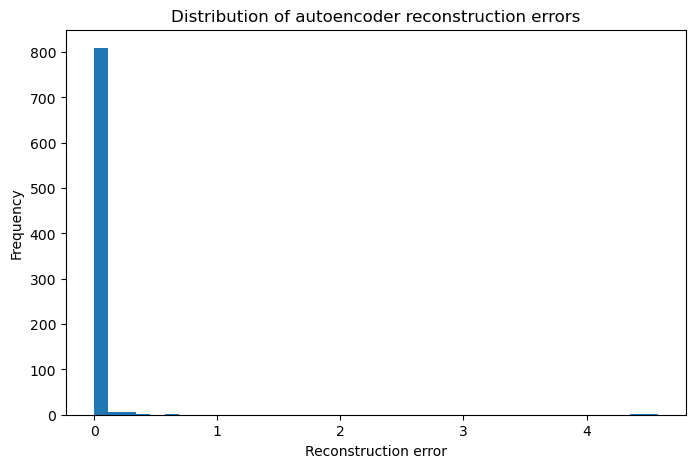

In [107]:
# Distribution of reconstruction error
plt.figure(figsize=(8, 5))
plt.hist(results_ae["reconstruction_error"], bins=40)
plt.xlabel("Reconstruction error")
plt.ylabel("Frequency")
plt.title("Distribution of autoencoder reconstruction errors")
plt.show()

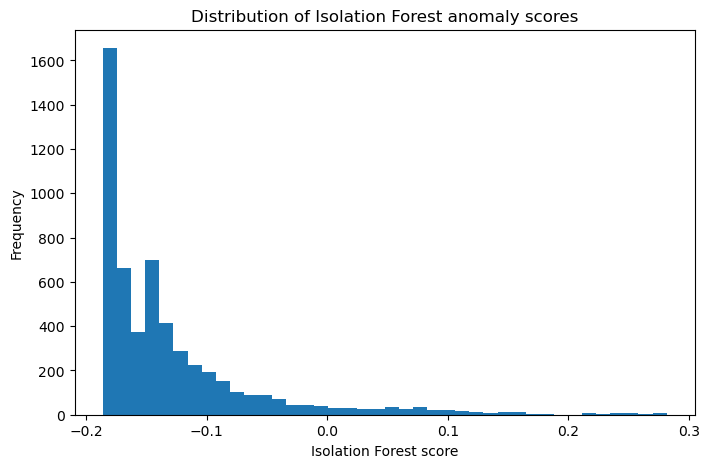

In [108]:
# Distribution of Isolation Forest scores
plt.figure(figsize=(8, 5))
plt.hist(results_if["if_score"], bins=40)
plt.xlabel("Isolation Forest score")
plt.ylabel("Frequency")
plt.title("Distribution of Isolation Forest anomaly scores")
plt.show()

### 7.7 Combined ranking of anomalies

This subsection combines the anomaly outputs from the two models into a shared comparison table.

The purpose is to summarize the strongest anomaly candidates across methods and provide a final result set that can be used in the discussion and conclusion.

In [112]:
# Add a baseline flag for top Isolation Forest anomalies
top_if_pairs = set(zip(top_if["municipality"], top_if["year"]))
comparison_df["top_if_flag"] = comparison_df.apply(
    lambda row: (row["municipality"], row["year"]) in top_if_pairs,
    axis=1
)

comparison_df.sort_values("reconstruction_error", ascending=False).head(15)

,municipality,year,reconstruction_error,ae_anomaly_flag,if_score,top_if_flag
57,0180 Stockholm,2019,4.578486,True,0.243338,False
798,0180 Stockholm,2009,4.424507,True,0.224906,False
119,1480 Göteborg,2005,0.639789,True,0.246837,False
64,1480 Göteborg,2019,0.397143,True,0.221474,False
751,0180 Stockholm,2013,0.295763,True,0.276569,True
477,0180 Stockholm,2010,0.295484,True,0.281378,True
535,0180 Stockholm,2015,0.248969,True,0.257026,False
468,2283 Sollefteå,2022,0.232088,True,-0.088311,False
627,0180 Stockholm,2006,0.229039,True,0.212344,False
773,1480 Göteborg,2008,0.188007,True,0.269774,True


## 8. Discussion

### 8.1 Interpretation of the results

The results show that anomaly detection can identify municipality-year observations with unusual energy profiles.

The two models did not produce the same top-10 ranking, which suggests that they capture unusual patterns in different ways. Isolation Forest and the autoencoder therefore provide complementary perspectives on the data.

The combined ranking was useful because it highlighted observations that received relatively high anomaly scores in both models. These observations form the strongest candidates for unusual municipality-year energy profiles in the dataset.

### 8.2 Limitations and possible improvements

This project has several limitations.

First, the dataset does not contain labeled anomalies. This means that the results can identify unusual observations, but they cannot prove whether those observations are true anomalies in a real-world sense.

Because the dataset does not contain labeled anomalies, the results should be interpreted as ranked candidates for unusual observations rather than verified anomalies.

Second, missing values were handled with a simple imputation strategy. This made the data usable for modeling, but other imputation methods could also be explored.

Third, the model development was kept deliberately simple. Isolation Forest was used as a baseline, and the autoencoder used a limited and transparent architecture. More tuning of the autoencoder could improve the results.

If the project were continued, possible improvements would include more feature engineering, more systematic tuning of the autoencoder, and external validation using additional information about municipalities, policy changes, or known events in the energy system.

### 8.3 Practical use and deployment architecture

In a real setting, this type of system could be used as a screening tool rather than as a fully automated decision system.

Instead of directly making decisions, the models could help identify municipality-year observations that deserve further investigation. This could support analysts working with energy planning, monitoring, policy evaluation, or quality control of reported data.

The current project was developed in a notebook environment, but in a practical deployment setting the workflow would need to be organized as a more structured pipeline. Such a pipeline would include data ingestion, preprocessing, model training, anomaly scoring, and reporting.

If new data were added regularly, the models could be retrained periodically and then used to score new municipality-year observations. The resulting anomaly scores could be stored in a reporting system or database and reviewed by domain experts as part of a broader analytical process.

This means that the main practical value of the system is not to replace human judgment, but to support analysts by narrowing attention to observations that appear most unusual and therefore deserve closer inspection.

### 8.4 Scalability

The current solution is suitable for a moderate tabular dataset and can be run on a standard local machine.

If the number of observations, years, or variables increased substantially, both preprocessing and repeated model training would become more computationally demanding.

For Isolation Forest, repeated parameter testing becomes more expensive as the dataset grows. For the autoencoder, resource usage depends on the size of the feature matrix, the number of training observations, and the available compute resources.

In a larger setting, batched training, more automated data pipelines, and possibly GPU-based training would become more relevant. If the system were scaled further or integrated into a broader analytical platform, distributed storage and distributed processing could also become relevant.

## 9. Conclusion

This project investigated whether anomaly detection methods could be used to identify unusual municipality-year energy profiles in Swedish municipal energy data.

The results show that this is possible. Isolation Forest provided a useful unsupervised baseline ranking, while the autoencoder offered a reconstruction-based neural-network approach that identified observations that were difficult to reconstruct. Together, the two models provided complementary perspectives on unusual energy patterns in the dataset.

The threshold-based analysis showed that the final number of flagged anomalies depends on how the anomaly cut-off is defined. In addition, the comparison between the two models showed that the strongest anomaly candidates were those that received relatively high anomaly scores across methods. These observations can therefore be interpreted as the most robust candidates for unusual municipality-year energy profiles.

At the same time, the dataset does not contain labeled anomalies, which means that the results should not be interpreted as verified real-world anomalies. Instead, the investigation should be understood as a structured and technically grounded ranking of unusual observations for further review.

Overall, the project demonstrates a complete anomaly detection workflow, from data preparation and baseline modeling to neural-network tuning, threshold selection, and comparative evaluation. The approach could be extended further through richer feature engineering, improved validation, and more scalable deployment in a larger analytical setting.

## 10. References (En del ex)

- Statistics Sweden (SCB). Municipal energy statistics datasets used in this project:
  - Final energy use (MWh), by county and municipality, consumption category and fuel type, 2005–2008 and 2009–2023.
  - Electricity production and fuel use (MWh), by county and municipality, production type and fuel type, 2005–2008 and 2009–2023.
  - District heating production and fuel use (MWh), by county and municipality, production type and fuel type, 2005–2008 and 2009–2023.

- Chandola, V., Banerjee, A., & Kumar, V. (2009). Anomaly detection: A survey. *ACM Computing Surveys*, 41(3), 1–58.

- Chollet, F. (2021). *Deep Learning with Python* (2nd ed.). Manning.

- Course lectures in Big Data Programming:
  - Deep Learning with Keras
  - Deep Learning with Keras 2 + TensorFlow
  - Anomaly Detection; AutoEncoders & GAN